<a href="https://colab.research.google.com/github/Gulshan-heap/House-Price-Prediction/blob/main/Week1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# TASK 1: DATA LOADING & EXPLORATION

In [2]:
# Load the CSV file
df = pd.read_csv("Housing.csv")

In [3]:
# Displaying the first 10 rows
print("--- First 10 Rows ---")
print(df.head(10))

--- First 10 Rows ---
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no         

In [4]:
# Check Dimensions
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset Shape: 545 rows, 13 columns


In [5]:
# Identify target and features
print("Target Variable: 'price'")
print("Feature Variables:", list(df.columns.drop('price')))

Target Variable: 'price'
Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
# Missing values
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())


--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# TASK 2: DATA CLEANING

In [7]:
# Handling missing values
# (The standard Kaggle dataset has 0 missing values, but this step guards it)
df = df.dropna()

In [8]:
# Removing duplicates
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows.")


Removed 0 duplicate rows.


In [9]:
# Convert categorical columns (yes/no, furnishingstatus) using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True,dtype=int)

print("\nEncoded Dataset Sample:")
df = df_encoded
print(df.head(3))


Encoded Dataset Sample:
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1                                0                             0  
1             0                                0                             0  
2             1                                1                             0  


In [10]:
# Keeping only meaningful columns
# Calculating absolute correlation of all features with the target variable (price)
correlations = df_encoded.corr()['price'].abs()

print(" --- Feature Correlation with Price --- ")
print(correlations.sort_values(ascending=False))

 --- Feature Correlation with Price --- 
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished       0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64


In [11]:
# Define a threshold: keep features with an absolute correlation greater than 0.20
threshold = 0.20
meaningful_features = correlations[correlations >= threshold].index

# Filter our dataset to keep only these meaningful columns
df_final = df_encoded[meaningful_features]

print(f"Task Complete: Retained {df_final.shape[1]} meaningful columns out of {df_encoded.shape[1]}.")
print("Dropped columns with weak price correlation (< 0.20):", list(set(df_encoded.columns) - set(df_final.columns)))

Task Complete: Retained 11 meaningful columns out of 14.
Dropped columns with weak price correlation (< 0.20): ['furnishingstatus_semi-furnished', 'hotwaterheating_yes', 'basement_yes']


In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


# TASK 3 — MODEL BUILDING

In [13]:
X = df_final.drop('price', axis=1)
y = df_final['price']

In [14]:
# Split into 80% Training and 20% Testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [17]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    max_features=0.6,
    bootstrap = True,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [19]:
# Performance Evaluation Function
def print_evaluation_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f" --- {model_name} Results --- ")
    print(f"Mean Absolute Error (MAE)     : ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R² Score                      : {r2:.4f}\n")

In [20]:
# Displaying Evaluations
print("--- MODEL PERFORMANCE EVALUATION ---")
print_evaluation_metrics("Linear Regression Model", y_test, lr_predictions)
print_evaluation_metrics("Random Forest Regressor", y_test, rf_preds)

--- MODEL PERFORMANCE EVALUATION ---
 --- Linear Regression Model Results --- 
Mean Absolute Error (MAE)     : $964,971.86
Root Mean Squared Error (RMSE): $1,339,904.16
R² Score                      : 0.6448

 --- Random Forest Regressor Results --- 
Mean Absolute Error (MAE)     : $1,007,505.10
Root Mean Squared Error (RMSE): $1,372,854.17
R² Score                      : 0.6271



# TASK 4 — VISUALIZATION

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

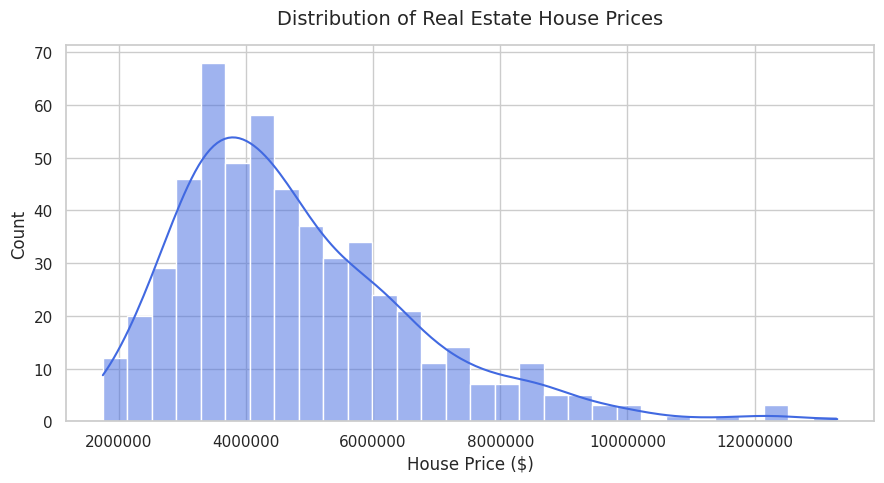

In [23]:
# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(9, 5))
sns.histplot(df_final['price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Real Estate House Prices', fontsize=14, pad=15)
plt.xlabel('House Price ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=300)
plt.show()

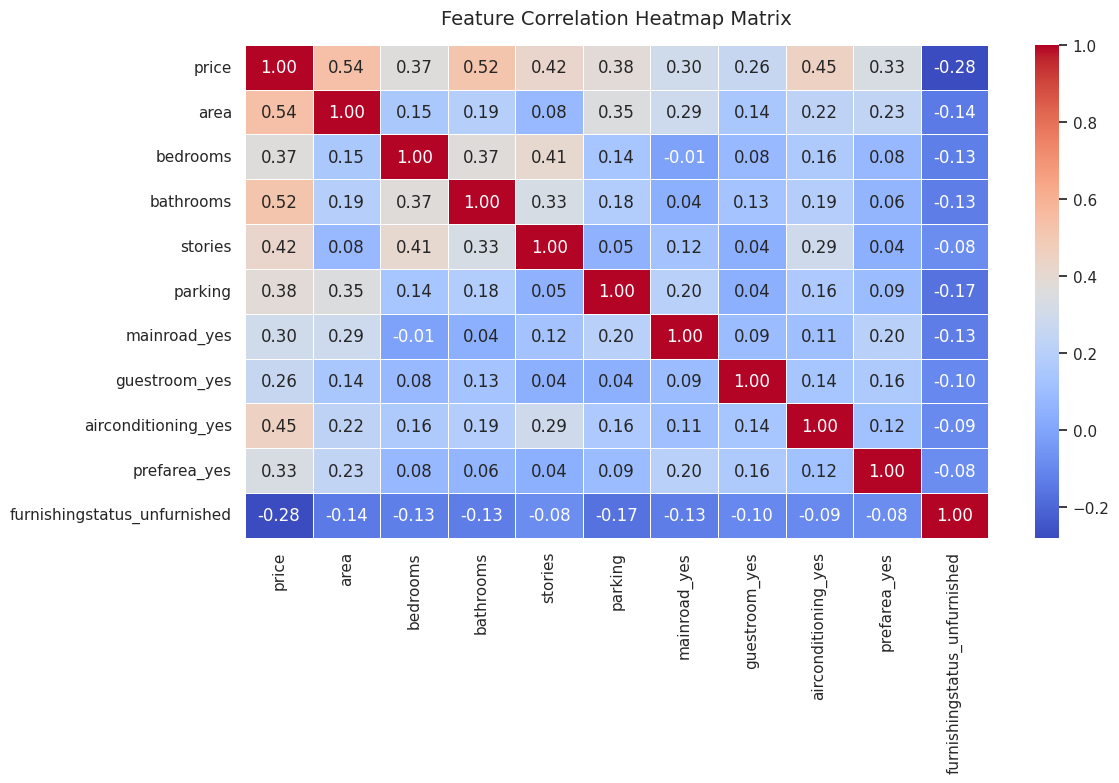

In [24]:
# Chart 2: Correlation heatmap showing feature relationships
plt.figure(figsize=(12, 8))
# Calculating correlation across the encoded dataframe to capture numeric fields
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Feature Correlation Heatmap Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=300)
plt.show()

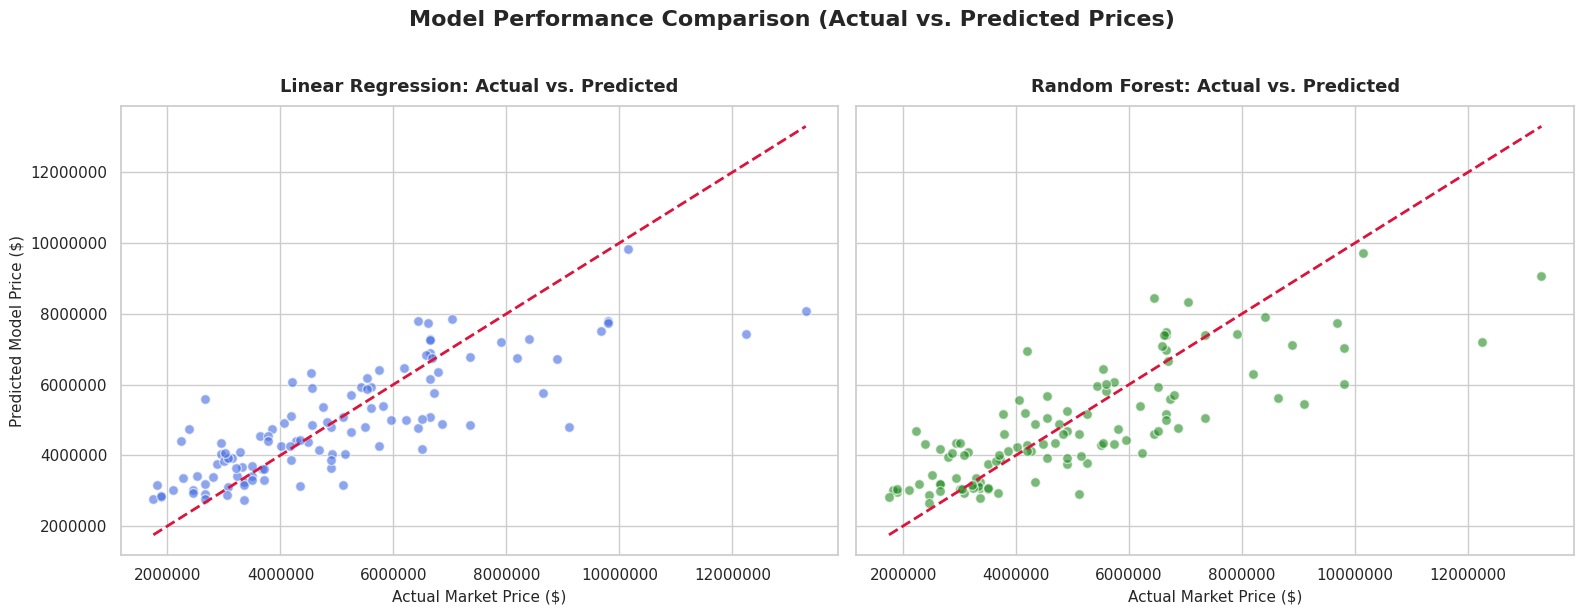

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Subplot 1: Linear Regression
axes[0].scatter(y_test, lr_predictions, alpha=0.6, color='royalblue', edgecolors='w', s=50)
# Diagonal reference line representing perfect predictions
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', lw=2, linestyle='--')
axes[0].set_title('Linear Regression: Actual vs. Predicted', fontsize=13, pad=10, weight='semibold')
axes[0].set_xlabel('Actual Market Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Model Price ($)', fontsize=11)
axes[0].ticklabel_format(style='plain', axis='both')

# Subplot 2: Random Forest
axes[1].scatter(y_test, rf_preds, alpha=0.6, color='forestgreen', edgecolors='w', s=50)
# Diagonal reference line representing perfect predictions
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', lw=2, linestyle='--')
axes[1].set_title('Random Forest: Actual vs. Predicted', fontsize=13, pad=10, weight='semibold')
axes[1].set_xlabel('Actual Market Price ($)', fontsize=11)
axes[1].ticklabel_format(style='plain', axis='both')

plt.suptitle('Model Performance Comparison (Actual vs. Predicted Prices)', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()

# Save the updated comparison chart
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# TASK 5 - INSIGHTS & SUMMARY

Based on our analysis of the housing dataset, property area size, the number of bathrooms, and air conditioning stand out as the primary features influencing real estate price variations. In our modeling tasks, the Linear Regression model achieved a higher $R^2$ score of 64.48%, outperforming the Random Forest Regressor, which achieved 62.71%. This performance gap is a meaningful finding: because the dataset is relatively compact (under 600 rows) and features highly linear structural parameters, the simpler Linear Regression model generalized much better without overfitting the training variables. What surprised us in the data was that additions like guestrooms or basements yielded a lower market premium relative to functional climate additions like central cooling units. Based on these insights, we recommend that real estate investment firms prioritize acquisitions with optimized lot layouts, multi-bathroom configurations, and pre-installed air conditioning systems, as these specific characteristics consistently command the highest organic valuation premiums.